# Original 69-Feature LightGBM Baseline

This diagnostic experiment compares LightGBM on the normalized original features against the 16-dimensional Autoencoder representation for S1 and S2.

In [1]:
# Cell 1 - Locate the project root and import notebook dependencies.
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

project_root = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'configs' / 'config.yaml').exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Project root: {project_root}')

Project root: e:\Paper Multiclass-Intrusion-Detection-System


In [2]:
# Cell 2 - Load configuration and verify original-feature plus target arrays.
from src.data_loading import load_config, resolve_project_path

config_path = project_root / 'configs' / 'config.yaml'
config = load_config(config_path)
processed_dir = resolve_project_path(config['paths']['processed_dir'], project_root)
metrics_dir = resolve_project_path(config['paths']['metrics_dir'], project_root)
figures_dir = resolve_project_path(config['paths']['figures_dir'], project_root)
required_paths = [
    processed_dir / 'X_train.npy',
    processed_dir / 'X_test.npy',
    processed_dir / 'y_train.npy',
    processed_dir / 'y_test.npy',
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f'Missing baseline input artifacts: {missing_paths}')

print(f"Original feature count: {config['data']['expected_feature_count']}")
print(f"Baseline scenarios: {config['baseline']['scenarios']}")

Original feature count: 69
Baseline scenarios: ['s1_none', 's2_class_weight']


In [3]:
# Cell 3 - Train missing original-feature models or reuse matching artifacts.
from src.baseline import run_original_feature_baseline

FORCE_RETRAIN_BASELINE = False
baseline_result = run_original_feature_baseline(
    config_path,
    force=FORCE_RETRAIN_BASELINE,
)
display(baseline_result['aggregate_comparison'])

,representation,scenario,accuracy,macro_precision,macro_recall,macro_f1,training_seconds
0,latent_16,s1_none,0.843600,0.320398,0.337571,0.314168,104.975497
1,latent_16,s2_class_weight,0.728500,0.410582,0.562000,0.424949,104.912774
2,original_69,s1_none,0.853090,0.354981,0.340097,0.337256,243.978489
3,original_69,s2_class_weight,0.788145,0.529813,0.648301,0.540644,208.435078


In [4]:
# Cell 4 - Verify that the controlled baseline changes only feature representation.
expected_iterations = int(config['lightgbm']['n_estimators'])
expected_features = int(config['data']['expected_feature_count'])
for scenario, report in baseline_result['training_reports'].items():
    assert report['representation'] == 'original_69', scenario
    assert report['feature_count'] == expected_features, scenario
    assert report['model_iterations'] == expected_iterations, scenario
    assert report['internal_validation'] is False, scenario
    assert report['all_configured_classes_predicted'], scenario
    if scenario == 's1_none':
        assert report['sample_weight_path'] is None
    if scenario == 's2_class_weight':
        assert report['sample_weight_path'] is not None

with open(metrics_dir / 'baseline_test_integrity.json', encoding='utf-8') as file:
    integrity = json.load(file)
assert integrity['test_artifacts_unchanged'] is True
assert integrity['test_hashes_before'] == integrity['test_hashes_after']
print('Controlled-baseline and test-integrity checks passed.')

Controlled-baseline and test-integrity checks passed.


In [5]:
# Cell 5 - Compare DoS, DDoS, and XSS metrics across representations.
focus = baseline_result['focus_comparison']
display(focus)

focus_pivot = focus.pivot(
    index=['scenario', 'class_name'],
    columns='representation',
    values=['recall', 'f1_score', 'paired_confusion_rate'],
)
display(focus_pivot)

,representation,scenario,class_name,precision,recall,f1_score,support,paired_confusion_count,paired_confusion_rate
0,latent_16,s1_none,DoS,0.020134,0.103448,0.033708,29,1.0,0.034483
1,latent_16,s1_none,DDoS,0.020833,0.025000,0.022727,40,8.0,0.200000
2,latent_16,s1_none,XSS,0.763308,0.924097,0.836042,429862,NaN,NaN
3,latent_16,s2_class_weight,DoS,0.000000,0.000000,0.000000,29,29.0,1.000000
4,latent_16,s2_class_weight,DDoS,0.020202,0.050000,0.028777,40,27.0,0.675000
5,latent_16,s2_class_weight,XSS,0.937559,0.489790,0.643440,429862,NaN,NaN
6,original_69,s1_none,DoS,0.000000,0.000000,0.000000,29,0.0,0.000000
7,original_69,s1_none,DDoS,0.000000,0.000000,0.000000,40,1.0,0.025000
8,original_69,s1_none,XSS,0.774807,0.930710,0.845633,429862,NaN,NaN
9,original_69,s2_class_weight,DoS,0.017241,0.034483,0.022989,29,28.0,0.965517


recall              f1_score              \
representation             latent_16 original_69 latent_16 original_69   
scenario        class_name                                               
s1_none         DDoS        0.025000    0.000000  0.022727    0.000000   
                DoS         0.103448    0.000000  0.033708    0.000000   
                XSS         0.924097    0.930710  0.836042    0.845633   
s2_class_weight DDoS        0.050000    0.000000  0.028777    0.000000   
                DoS         0.000000    0.034483  0.000000    0.022989   
                XSS         0.489790    0.587616  0.643440    0.732724   

                           paired_confusion_rate              
representation                         latent_16 original_69  
scenario        class_name                                    
s1_none         DDoS                    0.200000    0.025000  
                DoS                     0.034483    0.000000  
                XSS                          NaN         NaN  
s2_class_weight DDoS                    0.675000    0.700000  
                DoS                     1.000000    0.965517  
                XSS                          NaN         NaN

In [6]:
# Cell 6 - Review the data-driven diagnosis for Autoencoder information loss.
diagnostic = baseline_result['diagnostic']
print(diagnostic['diagnosis'])
print()
print(diagnostic['causal_limit'])

best_f1 = pd.DataFrame(diagnostic['dos_ddos_best_f1_by_representation'])
display(best_f1)
display(pd.DataFrame([diagnostic['aggregate_s2_effect']]))
display(pd.DataFrame([diagnostic['xss_s2_effect']]))

The original 69 features improve S2 macro F1 from 0.4249 to 0.5406, but they do not improve the best attainable F1-score for either DoS or DDoS. Their mutual confusion is therefore more consistent with intrinsic flow similarity and very small class supports than with Autoencoder information loss as the primary cause.

This controlled baseline changes the feature representation while keeping the split, LightGBM configuration, and S1/S2 handling fixed. It supports, but cannot alone prove, a causal explanation because DoS and DDoS supports remain extremely small.


,class_name,best_latent_f1,best_original_f1,best_f1_delta_original_minus_latent
0,DoS,0.033708,0.022989,-0.010719
1,DDoS,0.028777,0.000000,-0.028777


,latent_macro_f1,original_macro_f1,macro_f1_delta_original_minus_latent,latent_macro_recall,original_macro_recall
0,0.424949,0.540644,0.115695,0.562,0.648301


,latent_recall,original_recall,recall_delta_original_minus_latent,latent_f1,original_f1
0,0.48979,0.587616,0.097827,0.64344,0.732724


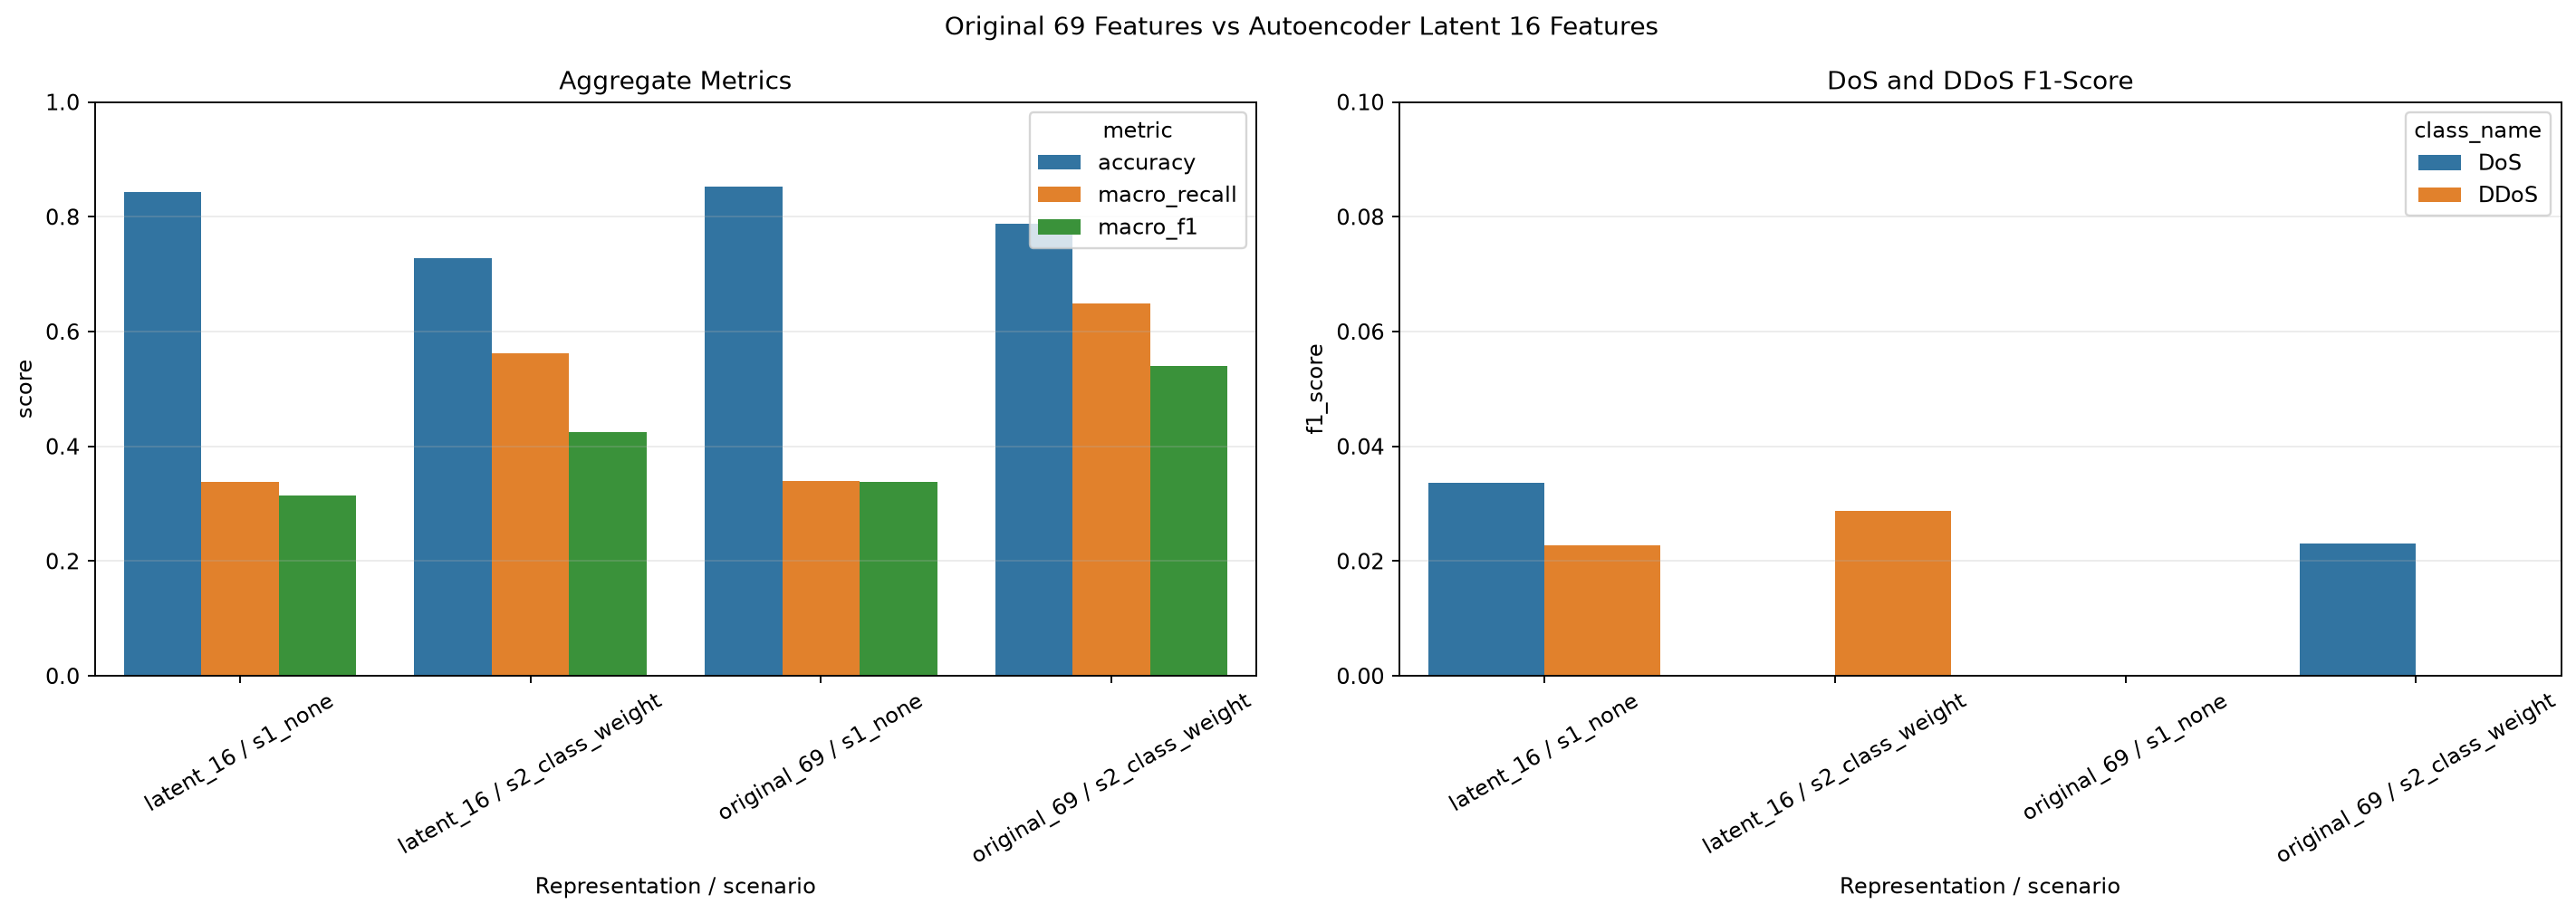

## Original 69 / s1_none

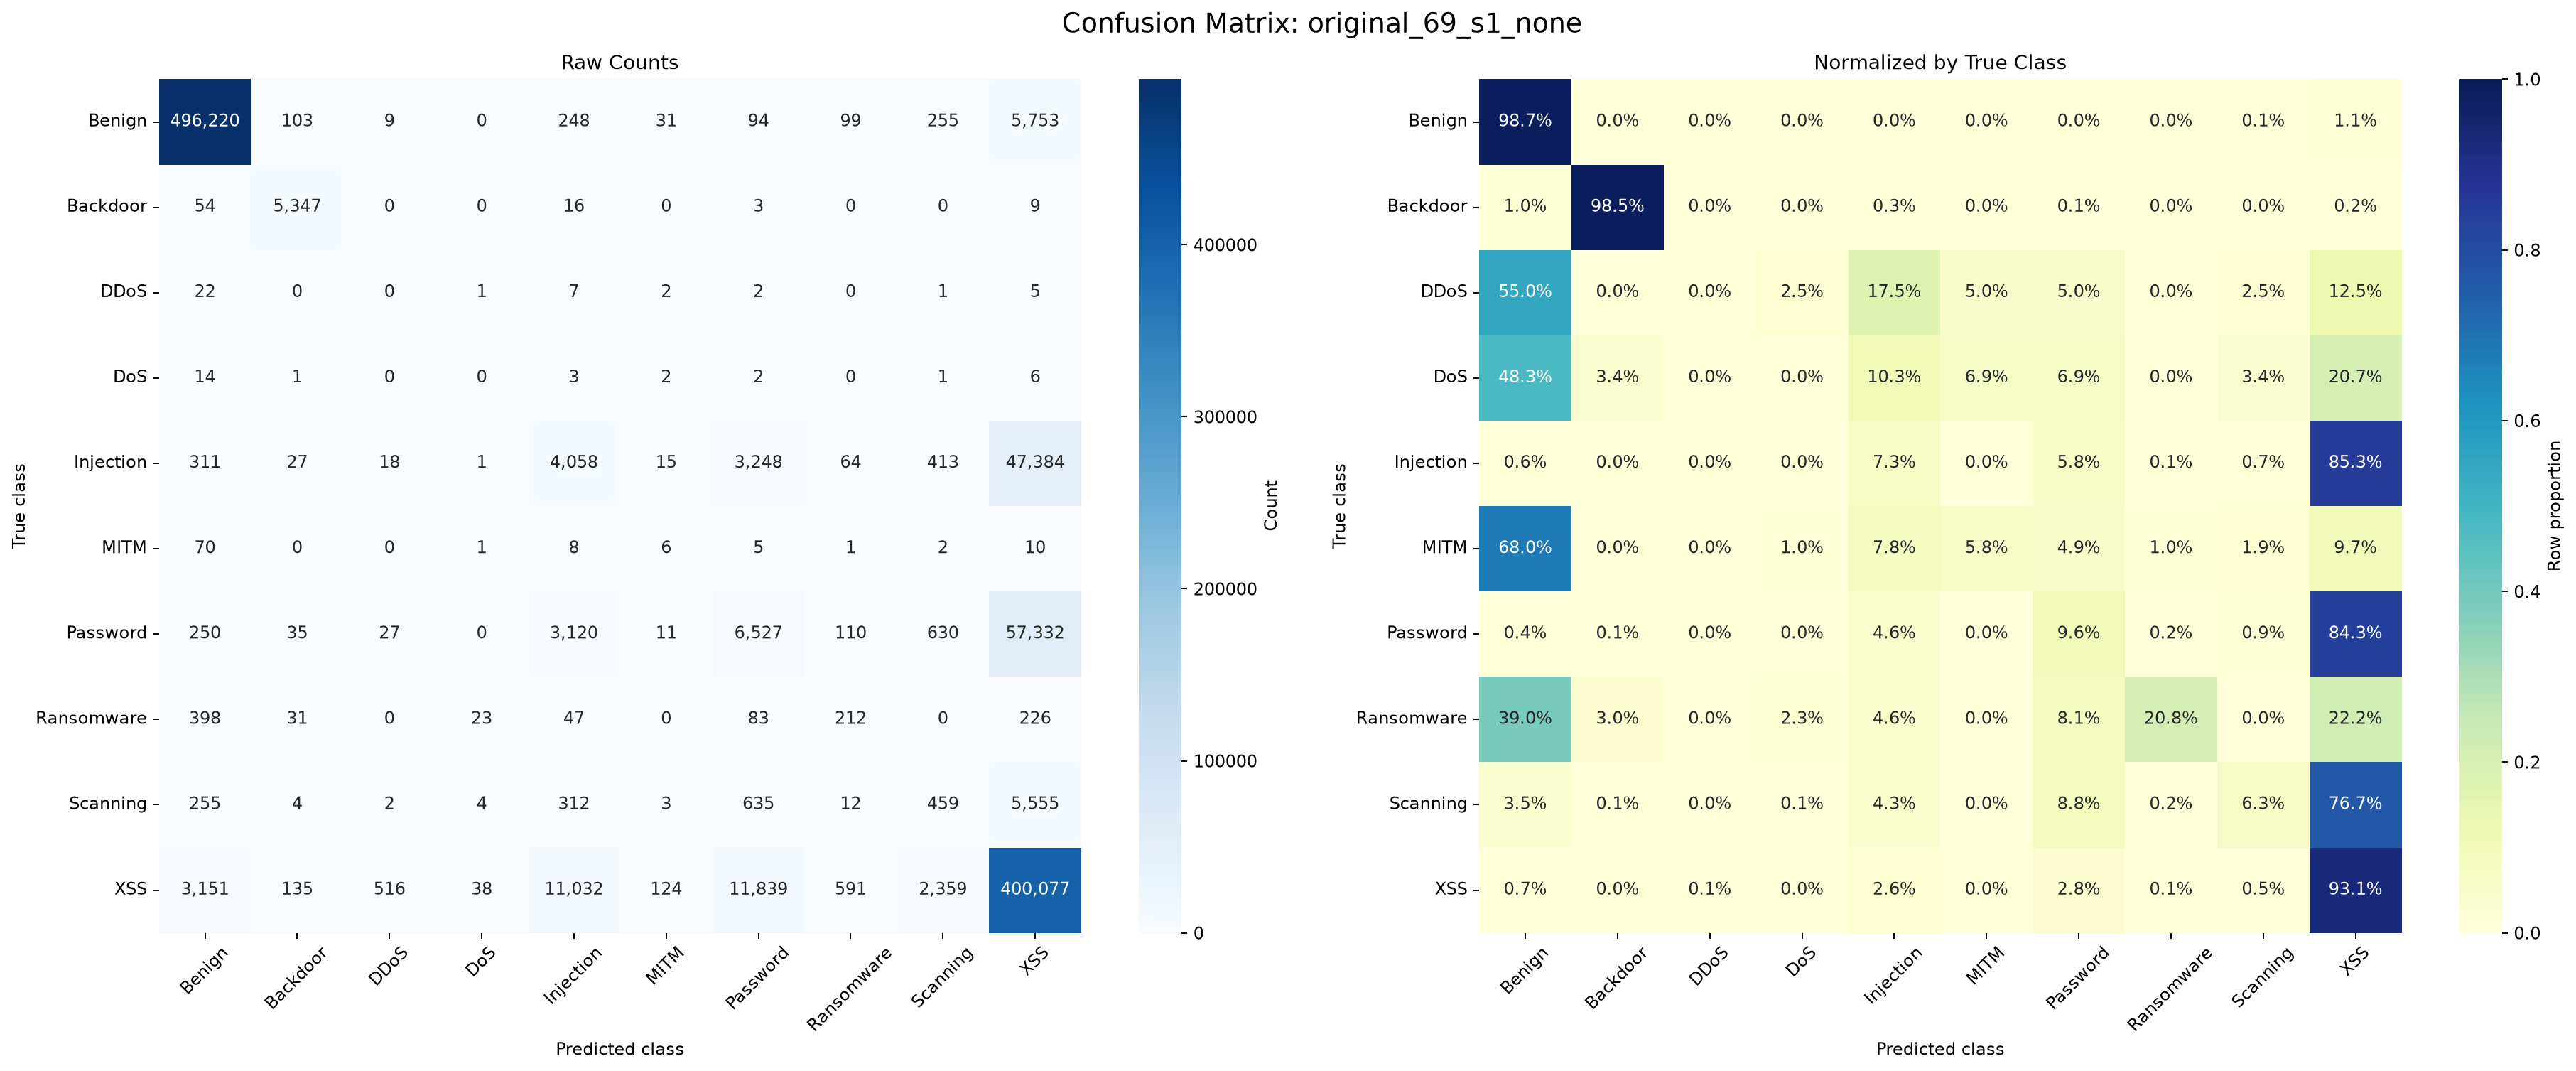

## Original 69 / s2_class_weight

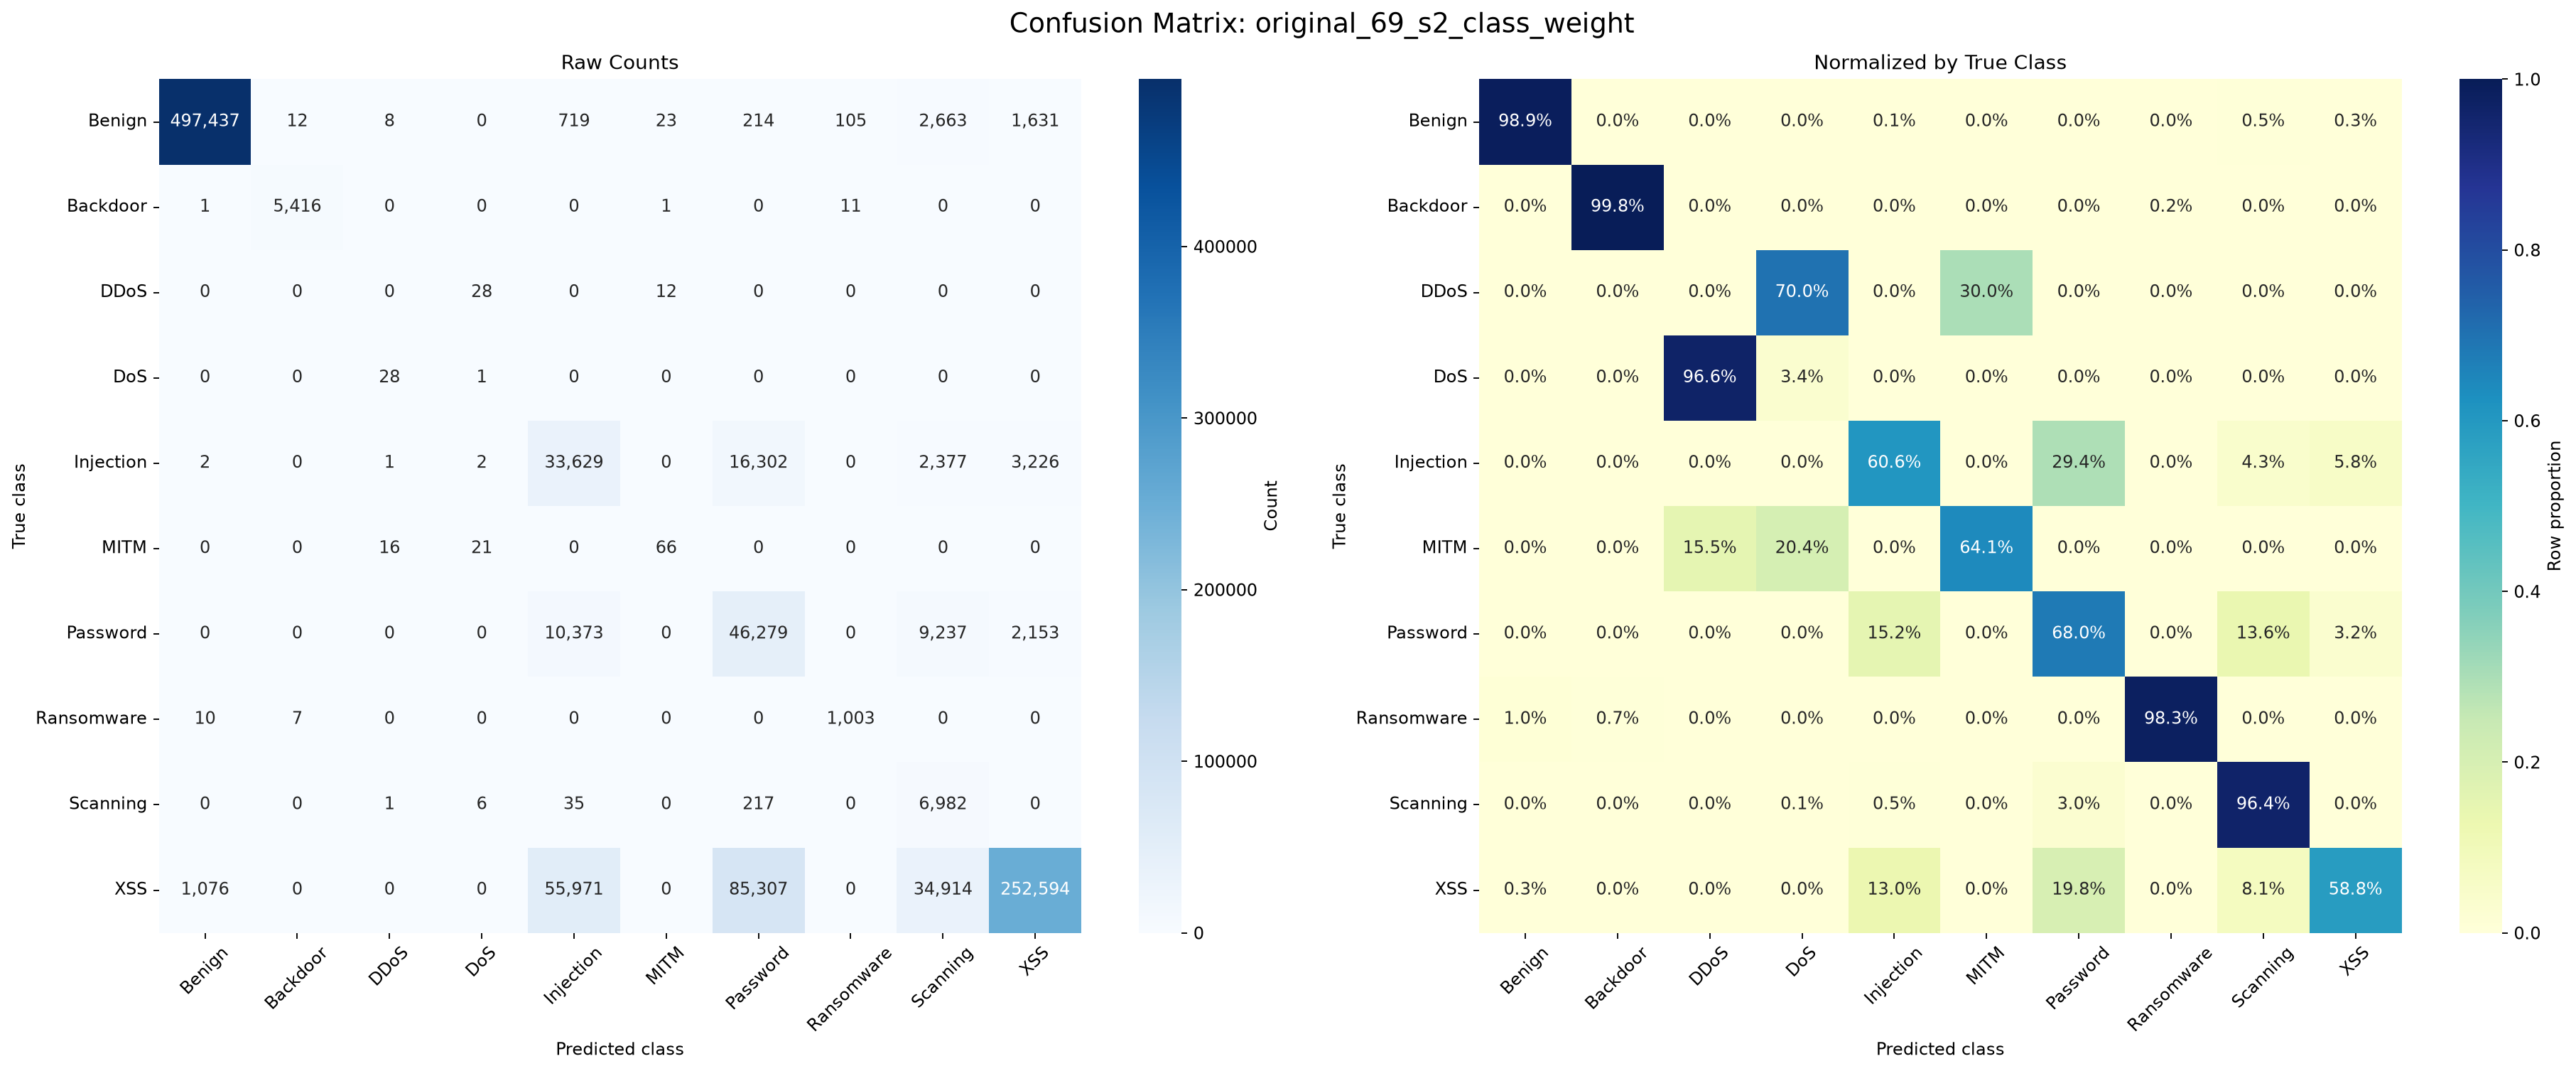

In [7]:
# Cell 7 - Display aggregate and confusion-matrix baseline figures.
display(Image(filename=baseline_result['figure_path']))
for scenario in config['baseline']['scenarios']:
    figure_path = figures_dir / f'confusion_matrix_original_69_{scenario}.png'
    if not figure_path.exists():
        raise FileNotFoundError(figure_path)
    display(Markdown(f'## Original 69 / {scenario}'))
    display(Image(filename=str(figure_path)))

In [8]:
# Cell 8 - List baseline artifacts prepared for the thesis discussion.
artifact_paths = [
    Path(baseline_result['aggregate_path']),
    Path(baseline_result['focus_path']),
    Path(baseline_result['diagnostic_path']),
    Path(baseline_result['figure_path']),
    Path(baseline_result['markdown_path']),
]
artifact_paths.extend(
    Path(report['model_path'])
    for report in baseline_result['training_reports'].values()
)
artifact_summary = pd.DataFrame({
    'artifact': [str(path) for path in artifact_paths],
    'exists': [path.exists() for path in artifact_paths],
})
assert artifact_summary['exists'].all()
display(artifact_summary)
print('Original-feature baseline artifacts are complete.')

,artifact,exists
0,E:\Paper Multiclass-Intrusion-Detection-System...,True
1,E:\Paper Multiclass-Intrusion-Detection-System...,True
2,E:\Paper Multiclass-Intrusion-Detection-System...,True
3,E:\Paper Multiclass-Intrusion-Detection-System...,True
4,E:\Paper Multiclass-Intrusion-Detection-System...,True
5,E:\Paper Multiclass-Intrusion-Detection-System...,True
6,E:\Paper Multiclass-Intrusion-Detection-System...,True


Original-feature baseline artifacts are complete.
